In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [29]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [31]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [32]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [33]:
df.isnull().sum().sum()

np.int64(0)

In [34]:
df["average_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [35]:
df[["math score", "reading score", "writing score", "average_score"]].describe() #Descriptive Statistics

,math score,reading score,writing score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


In [36]:
print("Mean:", df["average_score"].mean())
print("Median:", df["average_score"].median())
print("Mode:", df["average_score"].mode()[0])

Mean: 67.77066666666666
Median: 68.33333333333333
Mode: 68.0


In [37]:
print("Standard Deviation:", df["average_score"].std())
print("Variance:", df["average_score"].var())
#Standard deviation tells how much scores vary from average.

#High standard deviation = students’ performance is spread out.

Standard Deviation: 14.257325984669153
Variance: 203.27134423312222


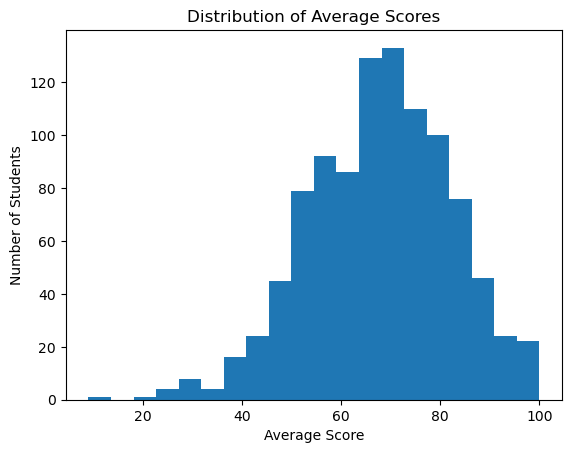

In [38]:
plt.hist(df["average_score"], bins=20 )
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Average Scores")
plt.show()
#This shows whether scores are normally distributed or skewed.

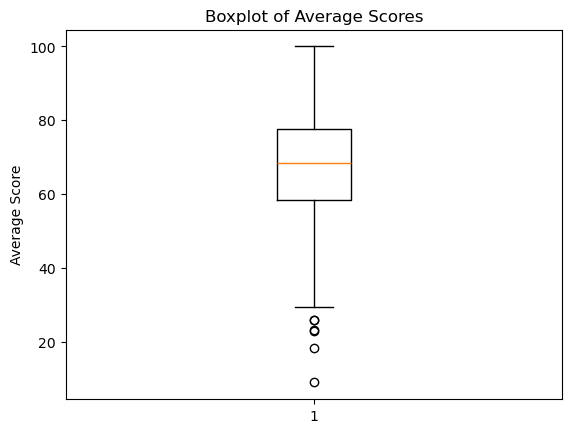

In [39]:
plt.boxplot(df["average_score"])
plt.title("Boxplot of Average Scores")
plt.ylabel("Average Score")
plt.show()

In [40]:
Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["average_score"] < lower_limit) | (df["average_score"] > upper_limit)]

outliers
#I used the IQR method to detect unusual student performance values.
#This helped identify students scoring extremely low or extremely high compared to the majority.

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000
59,female,group C,some high school,free/reduced,none,0,17,10,9.000000
76,male,group E,some high school,standard,none,30,26,22,26.000000
327,male,group A,some college,free/reduced,none,28,23,19,23.333333
596,male,group B,high school,free/reduced,none,30,24,15,23.000000
980,female,group B,high school,free/reduced,none,8,24,23,18.333333


In [41]:
#Hypothesis Test 1
#Question
#Do students who completed test preparation score higher than those who did not?

completed = df[df["test preparation course"] == "completed"]["average_score"]
none = df[df["test preparation course"] == "none"]["average_score"]

t_stat, p_value = stats.ttest_ind(completed, none)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.390944443482592
P-value: 1.633780203592351e-16


In [42]:
# for how to understandings
if p_value < 0.05:
    print("Result: Significant difference. Test preparation affects scores.")
else:
    print("Result: No significant difference.")

Result: Significant difference. Test preparation affects scores.


In [43]:
#I applied an independent t-test to compare average scores between students who completed test preparation and those who did not.
#Since the p-value was checked against 0.05, I could decide whether the difference was statistically significant.

In [44]:
#Hypothesis Test 2
#question
#Does parental education level affect student performance?

groups = []

for level in df["parental level of education"].unique():
    group_scores = df[df["parental level of education"] == level]["average_score"]
    groups.append(group_scores)

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

#Here we use ANOVA because we compare more than two groups.

F-statistic: 10.753146962336569
P-value: 4.3810464809431664e-10


In [45]:
#Correlation Analysis
correlation = df[["math score", "reading score", "writing score", "average_score"]].corr()

correlation

#Explanation
#Correlation shows relationship strength.
#Close to 1 = strong positive relationship
#Close to 0 = weak relationship
#Close to -1 = negative relationship

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000
